In [1]:
%pip install -r requirements-offline.txt --quiet

/Users/utarn/projects/ml-metrology/.claude/worktrees/issue-32/.check-env-m7/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


# Exercise — Module M7: Grad-CAM + metric รวมทุก modality

**วิธีทำ:** เติมช่อง `# TODO` / `...` ให้ทุกเซลล์รันผ่าน แล้วตอบคำถาม markdown ที่กำหนด — เปิด `book.ipynb` เทียบได้ตลอด (โค้ดชุดเดียวกัน)

**ควรรัน `book.ipynb` ให้จบก่อนหนึ่งรอบ** เพื่อให้มี checkpoint ที่ `data/m1_small_cnn.pt` — ถ้ายังไม่มี เซลล์เตรียมโมเดลด้านล่างจะเทรนใหม่ให้เอง (~1 นาที บน CPU)

**Dataset:** Fashion-MNIST — Xiao et al. (2017), arXiv:1708.07747, <https://github.com/zalandoresearch/fashion-mnist>, **License: MIT** · **วิธี:** Grad-CAM — Selvaraju et al., arXiv:1610.02391, <https://arxiv.org/abs/1610.02391>

**เวลาโดยประมาณ:** 15–20 นาที


## 0. เตรียมข้อมูล + โหลดโมเดลจาก M1 (ให้มาแล้ว — รันผ่าน)

โค้ดชุดนี้เหมือน book.ipynb ทุกอย่าง: subsample เดียวกับ M1 + โหลด checkpoint ถ้ามี / เทรนใหม่ถ้าไม่มี


In [2]:
from pathlib import Path


def repo_root() -> Path:
    """หา repo root โดยไล่ขึ้นจาก cwd."""
    for p in (Path.cwd(), *Path.cwd().parents):
        if (p / "requirements-offline.txt").exists():
            return p
    raise SystemExit(
        "ไม่พบ repo root — เปิด JupyterLab จาก repo root (uv run jupyter lab)"
    )


import os  # noqa: E402

# Fashion-MNIST: ใช้ datasets/fashion_mnist ที่ pre-bundle ไว้ก่อน
# (git LFS) — ถ้าไม่มีค่อยดาวน์โหลดลง data/ (gitignored) ตามเดิม
_fm = repo_root() / "datasets" / "fashion_mnist" / "FashionMNIST"
if _fm.exists():
    DATA = repo_root() / "datasets" / "fashion_mnist"
else:
    DATA = repo_root() / "data"

# weights ของ torchvision (MobileNetV3) — ใช้ datasets/models/torch
# ที่ pre-bundle ไว้ถ้ามี (torch.hub อ่าน TORCH_HOME ตอนโหลด weights)
_torch = repo_root() / "datasets" / "models" / "torch"
if _torch.exists():
    os.environ["TORCH_HOME"] = str(_torch)



In [3]:
import numpy as np  # noqa: E402
from torchvision.datasets import FashionMNIST  # noqa: E402

# download=True: โหลดจากดิสก์ทันทีบนเครื่อง offline ที่ pre-bundle ไว้แล้ว
train_full = FashionMNIST(root=DATA, train=True, download=True)
test_full = FashionMNIST(root=DATA, train=False, download=True)
print(train_full.data.shape, test_full.data.shape)


torch.Size([60000, 28, 28]) torch.Size([10000, 28, 28])


In [4]:
# fixed subsample 10k/2k — ชุดเดียวกับ M1 เป๊ะ (seed 42)
N_TRAIN, N_TEST = 10_000, 2_000
rng = np.random.default_rng(42)
idx_tr = rng.choice(len(train_full.data), N_TRAIN, replace=False)
idx_te = rng.choice(len(test_full.data), N_TEST, replace=False)
X_train = train_full.data.numpy()[idx_tr]
y_train = train_full.targets.numpy()[idx_tr]
X_test = test_full.data.numpy()[idx_te]
y_test = test_full.targets.numpy()[idx_te]
CLASS_EN = [
    "T-shirt", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
]
print(X_train.shape, X_test.shape)


(10000, 28, 28) (2000, 28, 28)


In [5]:
import torch  # noqa: E402
import torch.nn as nn  # noqa: E402
from torch.utils.data import DataLoader, TensorDataset  # noqa: E402

Xtr_t = torch.from_numpy(X_train).float().unsqueeze(1) / 255.0
Xte_t = torch.from_numpy(X_test).float().unsqueeze(1) / 255.0
ytr_t = torch.from_numpy(y_train)
mean, std = Xtr_t.mean(), Xtr_t.std()
Xtr_n = (Xtr_t - mean) / std
Xte_n = (Xte_t - mean) / std
print(f"normalize: mean={mean:.4f} std={std:.4f}")


class SmallCNN(nn.Module):
    """CNN จิ๋ว 2 ชั้น conv — สถาปัตยกรรมเดียวกับ M1 (copy มาใช้)."""

    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(32 * 7 * 7, 10),
        )

    def forward(self, x):
        return self.net(x)


def train_cnn(X, y, epochs=10, bs=128, seed=0, log_every=0):
    """เทรน CNN ด้วย Adam คืนโมเดลที่เทรนแล้ว (โค้ดเดียวกับ M1)."""
    torch.manual_seed(seed)
    model = SmallCNN()
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()
    g = torch.Generator().manual_seed(seed)
    dl = DataLoader(
        TensorDataset(X, y), batch_size=bs, shuffle=True, generator=g
    )
    for ep in range(epochs):
        model.train()
        for xb, yb in dl:
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()
        if log_every and (ep + 1) % log_every == 0:
            print(f"  epoch {ep + 1}/{epochs}: loss={loss.item():.4f}")
    return model


def cnn_accuracy(model):
    model.eval()
    with torch.no_grad():
        pred = model(Xte_n).argmax(1).numpy()
    return accuracy_score(y_test, pred)


normalize: mean=0.2867 std=0.3535


In [6]:
from sklearn.metrics import accuracy_score  # noqa: E402

CKPT = DATA / "m1_small_cnn.pt"
cnn = SmallCNN()
if CKPT.exists():
    cnn.load_state_dict(
        torch.load(CKPT, map_location="cpu", weights_only=True)
    )
    print("โหลด checkpoint จาก:", CKPT)
else:
    print("ยังไม่มี checkpoint — เทรนใหม่ 10 epochs (~1 นาที บน CPU)")
    cnn = train_cnn(Xtr_n, ytr_t, epochs=10, log_every=2)
    torch.save(cnn.state_dict(), CKPT)
    print("เซฟ checkpoint ไว้ใช้รอบหน้าที่:", CKPT)

cnn.eval()
with torch.no_grad():
    preds = cnn(Xte_n).argmax(1).numpy()
acc_cnn = accuracy_score(y_test, preds)
print(f"CNN accuracy = {acc_cnn:.4f}  (M1 ได้ราว 0.86-0.88)")


โหลด checkpoint จาก: /Users/utarn/projects/ml-metrology/.claude/worktrees/issue-32/data/m1_small_cnn.pt
CNN accuracy = 0.8745  (M1 ได้ราว 0.86-0.88)


In [7]:
cnn.eval()
with torch.no_grad():
    preds = cnn(Xte_n).argmax(1).numpy()
ok_idx = np.where(preds == y_test)[0]
wrong_idx = np.where(preds != y_test)[0]
print(f"accuracy = {(preds == y_test).mean():.4f} — "
      f"ถูก {len(ok_idx)} / ผิด {len(wrong_idx)} ภาพ")


accuracy = 0.8745 — ถูก 1749 / ผิด 251 ภาพ


In [8]:
import torch.nn.functional as F  # noqa: E402


class GradCAM:
    """Grad-CAM (Selvaraju et al., 2017) ด้วย torch hooks.

    forward hook จับ activation ของชั้น conv เป้าหมาย แล้วติด tensor
    hook ต่อเพื่อจับ gradient ของ feature map ตอน backward
    """

    def __init__(self, model, target_layer):
        self.model = model
        self.acts = None
        self.grads = None
        target_layer.register_forward_hook(self._save_act)

    def _save_act(self, module, inp, out):
        self.acts = out.detach()
        out.register_hook(self._save_grad)  # gradient ของ feature map

    def _save_grad(self, grad):
        self.grads = grad.detach()

    def cam(self, x, class_idx=None):
        """คืน (heatmap 28x28 ที่ normalize 0-1, class ที่คำนวณด้วย)."""
        self.model.eval()
        out = self.model(x)
        if class_idx is None:
            class_idx = int(out[0].argmax())
        self.model.zero_grad()
        out[0, class_idx].backward()
        w = self.grads[0].mean(dim=(1, 2))  # alpha_k — GAP ของ gradient
        cam = torch.relu((w[:, None, None] * self.acts[0]).sum(0))
        if cam.max() > 0:
            cam = cam / cam.max()
        cam28 = F.interpolate(
            cam[None, None], size=(28, 28), mode="bilinear",
            align_corners=False,
        )[0, 0]
        return cam28.numpy(), class_idx


import matplotlib.pyplot as plt  # noqa: E402

cammer = GradCAM(cnn, cnn.net[3])  # Conv2d(16->32) — ชั้น conv สุดท้าย


def show_cam(i, class_idx=None):
    """แสดงภาพที่ i ซ้อน CAM — default: CAM ของ class ที่โมเดลทำนาย."""
    heat, p = cammer.cam(Xte_n[i:i + 1], class_idx=class_idx)
    plt.figure(figsize=(2.4, 2.6))
    plt.imshow(X_test[i], cmap="gray")
    plt.imshow(heat, cmap="magma", alpha=0.55)
    plt.title(f"true={CLASS_EN[y_test[i]]}  pred={CLASS_EN[p]}", fontsize=9)
    plt.axis("off")
    plt.show()


## ข้อ 1 — ชั้นไหน "เห็น" อะไร: conv แรก vs conv สุดท้าย

สร้าง `GradCAM` ที่ hook **ชั้น conv แรก** (`cnn.net[0]` — output 28×28, ยังไม่ผ่าน pool) เทียบกับ `cammer` ที่ hook ชั้นสุดท้าย (7×7) บนภาพที่โมเดลทำถูก 3 ภาพแรก แสดงเทียบกัน 3 คอลัมน์: ต้นฉบับ / CAM ชั้นแรก / CAM ชั้นสุดท้าย (ใช้ CAM ของ class ที่โมเดลทำนาย)

**คำถาม:** heatmap ต่างกันอย่างไร และเพราะอะไรชั้นลึกถึง "เข้าใจโจทย์" มากกว่า (ตอบใน markdown)


In [9]:
cam_first = GradCAM(cnn, ...)  # TODO: hook ชั้น conv แรก
for i in ok_idx[:3]:
    # TODO: สร้าง CAM จาก cam_first และจาก cammer
    #       (class_idx=int(preds[i])) แล้วพล็อตเทียบ 3 คอลัมน์
    ...


AttributeError: 'ellipsis' object has no attribute 'register_forward_hook'

คำตอบข้อ 1: (CAM ชั้นแรกละเอียดแต่ "ไม่ discriminative" — ชั้นสุดท้ายหยาบแต่โฟกัสสิ่งที่แยก class — เพราะอะไร)

## ข้อ 2 — สืบศาสดาภาพที่โมเดลผิด

เลือกภาพที่โมเดลผิดจาก `wrong_idx` **3 ภาพแรก** แสดง CAM สองแบบต่อภาพ: ของ class ที่โมเดลทำนาย (ผิด) และของ class จริง (ใช้ `show_cam(i)` และ `show_cam(i, class_idx=...)`)

**คำถาม:** โมเดล "มองถูกที่แต่ตีความผิด" หรือ "มองผิดที่ตั้งแต่ต้น" — อ้างจาก heatmap ที่เห็นจริง (ตอบใน markdown)


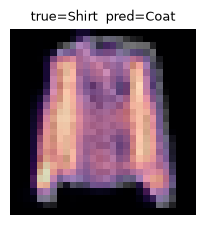

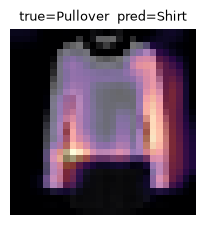

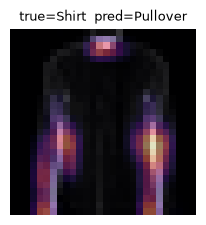

In [10]:
for i in wrong_idx[:3]:
    show_cam(i)  # CAM ของ class ที่โมเดลทำนาย (ผิด)
    # TODO: แสดง CAM ของ true class ของภาพ i ด้วย
    ...


คำตอบข้อ 2: (CAM สองแบบทับกันมากไหม — แปลว่าอะไร)

## ข้อ 3 — โปรแกรมหา class แย่สุด + คู่สับสนสูงสุด

จาก confusion matrix ของโมเดล: (1) คำนวณ error rate **ต่อ class** (`1 − diagonal / row sum`) (2) โปรแกรมหา **class ที่ error สูงสุด** และ **คู่สับสนสูงสุดนอกแนวทแยง** (เทคนิคเดียวกับ book: ตั้งแนวทแยงเป็น 0 แล้ว argmax) — พิมพ์ทั้งสองพร้อมชื่อ class


In [11]:
from sklearn.metrics import confusion_matrix  # noqa: E402

cm = confusion_matrix(y_test, preds)
# TODO: err_by_class — error rate ต่อ class (เวกเตอร์ 10 ค่า)
err_by_class = ...
# TODO: พิมพ์ class ที่ error สูงสุด และคู่สับสนสูงสุดนอกแนวทแยง
...


Ellipsis

คำตอบข้อ 3: (class ไหนแย่สุด คู่ไหนสับสนสูงสุด และสมเหตุสมผลไหม)

## ข้อ 4 — ตาราง metric ของคุณเอง

สร้างตารางเดียวกับ book §4 แต่ใช้**ค่าของคุณ**: accuracy จากแล็บนี้ (รันสด), CER จากการรัน M2 ของคุณ (ถ้ายังไม่ได้รัน ใช้ค่าตัวอย่าง 0.174 และทำเครื่องหมาย "ตัวอย่าง" ไว้ชัดเจน), WER จาก M5 (ถ้ายังไม่ได้รัน ใส่ค่าตัวอย่างเชิงประกอบพร้อมเครื่องหมาย)

**คำถาม:** ค่าไหน "แย่" ที่สุดเมื่อวัดในหน่วยของมันเอง — และเทียบข้าม modality ตรง ๆ ได้ไหม เพราะอะไร (ตอบใน markdown)


In [12]:
import pandas as pd  # noqa: E402, F401

my_rows = [
    {"modality": "ภาพ", "metric": "accuracy", "ค่าของคุณ": acc_cnn,
     "ที่มา": "รันสด"},
    {"modality": "OCR", "metric": "CER", "ค่าของคุณ": ...,
     "ที่มา": "TODO: จาก M2 ของคุณ (หรือค่าตัวอย่าง 0.174)"},
    {"modality": "เสียง", "metric": "WER", "ค่าของคุณ": ...,
     "ที่มา": "TODO: จาก M5 ของคุณ (หรือค่าตัวอย่างเชิงประกอบ)"},
]
# TODO: สร้าง DataFrame จาก my_rows แล้ว print
...


Ellipsis

คำตอบข้อ 4: (ค่าไหนแย่สุดในหน่วยตัวเอง — เทียบข้าม modality ตรง ๆ ไม่ได้เพราะอะไร)

## ข้อ 5 — ตัดสินใจแบบนักเมโทรโลยี (ตอบใน markdown)

หัวหน้าแผนกถาม: "**โมเดลจำแนกชิ้นงาน ปกติ/ชำรุด ที่คุณส่งมา เชื่อได้แค่ไหน**" — เขียนแผนตรวจสอบ **3 ขั้น**โดยใช้เครื่องมือจากโมดูลนี้ (Grad-CAM, error inspection 4 ขั้น, ตาราง metric รวม) ระบุให้ชัดว่าแต่ละขั้น**ตอบคำถามอะไร** และผลลัพธ์ของขั้นนั้นรูปแบบไหน (ตัวเลข/ภาพ/รายการ)


คำตอบข้อ 5: (แผน 3 ขั้น: วัด → ดู → ตัดสิน — แต่ละขั้นใช้เครื่องมือไหน ตอบคำถามอะไร)